In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [2]:
#Run this to use Latex-like font
plt.rcParams.update({
    "mathtext.fontset": "cm", # 'cm' for Computer Modern, 'stix' for Times-like
    "font.family": "serif",
    "axes.formatter.use_mathtext": True,
    "font.size":14,
    'axes.prop_cycle':plt.cycler(color=plt.cm.Set1.colors)
})

In [23]:
output = Path('./output')
files = [f.name for f in output.iterdir() if f.is_file()]
print(files)

def graph(file_name):
    temp = file_name[4:-4]
    file_path = "./output/"+file_name
    t, msd_array, correla_array = np.loadtxt(file_path, comments = "#", unpack = True)
    return temp, t, msd_array, correla_array

graph(files[1])[0]

['v_x_0.5000.dat', 'v_x_2.0000.dat', 'v_x_8.0000.dat']


'2.0000'

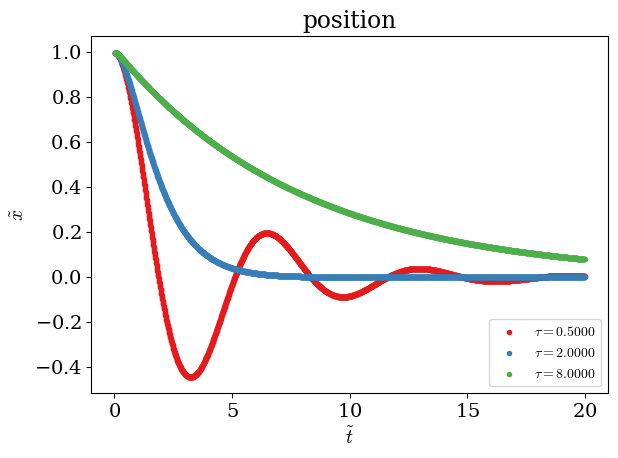

In [25]:
fig, ax  = plt.subplots()
ax.set_title("position")
for i in files:
    temp, t, msd,corre = graph(i)
    T = float(temp)
    xtemp = np.logspace(-2,1,base=10)
    ax.scatter(t,msd, label= rf"$\tau={T:.4f}$", marker='.')
    
ax.set_xlabel(r"$\tilde{t}$")
ax.set_ylabel(r"$\tilde{x}$")
#ax.plot(xtemp, MSD(xtemp, T), color='black', ls = 'dashed', label = rf"Theory")
ax.legend(loc='lower right', fontsize=10)

fig.tight_layout()
fig.savefig('./image/damped.png')